Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix

Load and Explore the Dataset

In [ ]:
# Load the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize the pixel values to range between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert the labels to one-hot encoded vectors
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Get the class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


170498071/170498071 [==============================] - 5s 0us/step


Data Preprocessing and Augmentation

In [ ]:
# Create data augmentation generator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Fit the generator on the training data
X_gen = datagen.fit(X_train)


Build the CNN Model

In [ ]:
# Initialize the CNN model
model = Sequential()

# Convolutional Layer
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
# Pooling layer
model.add(MaxPool2D(pool_size=(2, 2)))
# Dropout layers
model.add(Dropout(0.25))

model.add(Conv2D(filters=64, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters=128, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
# model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(10, activation='softmax'))

METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=METRICS)

 Model Training

In [ ]:
# Define the number of epochs and batch size
epochs = 50
batch_size = 64

# Train the model
history = model.fit(datagen.flow(X_train, y_train, batch_size=batch_size),
                    steps_per_epoch=len(X_train) // batch_size,
                    epochs=epochs,
                    validation_data=(X_test, y_test))

Epoch 1/50
781/781 [==============================] - 455s 578ms/step - loss: 1.6592 - accuracy: 0.4061 - precision: 0.6124 - recall: 0.1930 - val_loss: 1.2784 - val_accuracy: 0.5394 - val_precision: 0.6832 - val_recall: 0.4006
Epoch 2/50
781/781 [==============================] - 452s 579ms/step - loss: 1.2661 - accuracy: 0.5471 - precision: 0.7118 - recall: 0.3734 - val_loss: 1.0797 - val_accuracy: 0.6190 - val_precision: 0.7412 - val_recall: 0.5044
Epoch 3/50
781/781 [==============================] - 453s 579ms/step - loss: 1.0856 - accuracy: 0.6199 - precision: 0.7566 - recall: 0.4787 - val_loss: 0.9345 - val_accuracy: 0.6800 - val_precision: 0.7670 - val_recall: 0.5976
Epoch 4/50
781/781 [==============================] - 451s 577ms/step - loss: 0.9650 - accuracy: 0.6635 - precision: 0.7852 - recall: 0.5464 - val_loss: 1.1072 - val_accuracy: 0.6500 - val_precision: 0.7445 - val_recall: 0.5792
Epoch 5/50
781/781 [==============================] - 476s 609ms/step - loss: 0.8935 - a

Model Evaluation and Visualization

313/313 - 33s - loss: 0.4069 - accuracy: 0.8687 - precision: 0.8989 - recall: 0.8465 - 33s/epoch - 106ms/step


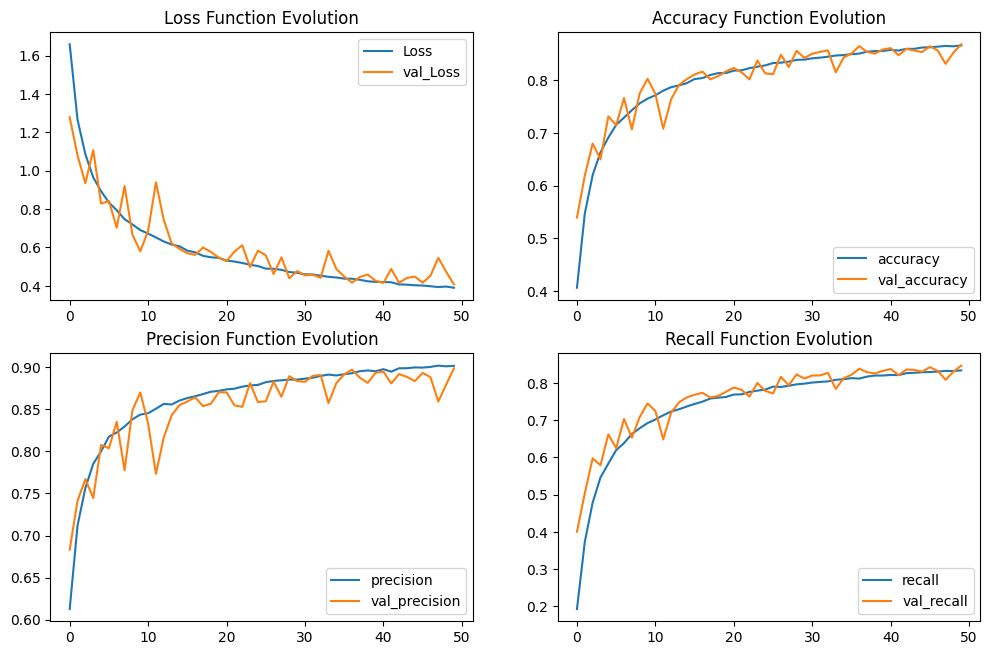

In [ ]:
# Evaluate the model on the test data
results = model.evaluate(X_test, y_test, verbose=2)
test_loss = results[0]
test_accuracy = results[1]

plt.figure(figsize=(12, 16))

plt.subplot(4, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='val_Loss')
plt.title('Loss Function Evolution')
plt.legend()

plt.subplot(4, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Function Evolution')
plt.legend()

plt.subplot(4, 2, 3)
plt.plot(history.history['precision'], label='precision')
plt.plot(history.history['val_precision'], label='val_precision')
plt.title('Precision Function Evolution')
plt.legend()

plt.subplot(4, 2, 4)
plt.plot(history.history['recall'], label='recall')
plt.plot(history.history['val_recall'], label='val_recall')
plt.title('Recall Function Evolution')
plt.legend()

In [ ]:
evaluation = model.evaluate(X_test, y_test)
print(f'Test Accuracy : {evaluation[1] * 100:.2f}%')

313/313 [==============================] - 21s 68ms/step - loss: 0.4069 - accuracy: 0.8687 - precision: 0.8989 - recall: 0.8465
Test Accuracy : 86.87%


Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Generate predictions on the test dataset
y_pred = model.predict(X_test)

# Convert the predicted class probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert the true class labels to one-hot encoded format
y_test_classes = np.argmax(y_test, axis=1)

# Generate a classification report
report = classification_report(y_test_classes, y_pred_classes, target_names=['class 0', 'class 1', 'class 2', 'class 3', 'class 4', 'class 5', 'class 6', 'class 7', 'class 8', 'class 9'])
print(report)


313/313 [==============================] - 23s 73ms/step
              precision    recall  f1-score   support

     class 0       0.86      0.90      0.88      1000
     class 1       0.92      0.96      0.94      1000
     class 2       0.83      0.83      0.83      1000
     class 3       0.86      0.65      0.74      1000
     class 4       0.85      0.87      0.86      1000
     class 5       0.87      0.76      0.81      1000
     class 6       0.81      0.95      0.87      1000
     class 7       0.89      0.92      0.90      1000
     class 8       0.96      0.89      0.93      1000
     class 9       0.84      0.95      0.89      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



Confusion Matrix

In [ ]:
y_test_arg=np.argmax(y_test,axis=1)
Y_pred = np.argmax(model.predict(X_test),axis=1)
print('Confusion Matrix')
print(confusion_matrix(y_test_arg, Y_pred))

313/313 [==============================] - 22s 69ms/step
Confusion Matrix
[[902  14  25   2   5   0   4   1  12  35]
 [  3 959   0   0   0   0   1   0   2  35]
 [ 32   1 835   8  33  14  50  16   2   9]
 [ 18  10  43 651  53  82  73  28   7  35]
 [  7   1  33  13 866   5  45  27   0   3]
 [ 10   3  35  71  29 763  33  40   1  15]
 [  6   3  14   8   6   4 948   3   4   4]
 [ 10   3  11   4  23   6   7 917   1  18]
 [ 53  18   2   1   1   0   7   1 891  26]
 [  4  31   2   1   0   0   1   1   5 955]]


313/313 [==============================] - 33s 103ms/step


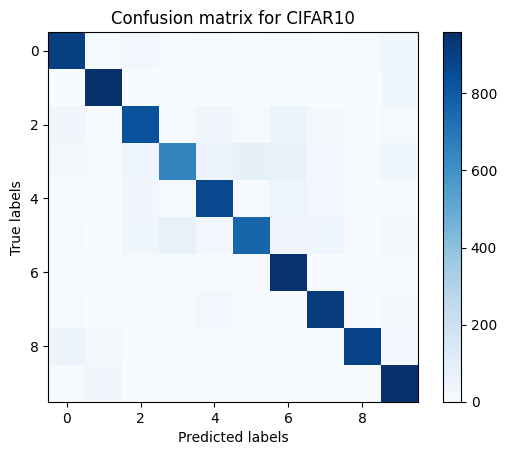

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Generate predictions on the test dataset
y_pred = model.predict(X_test)

# Convert the predicted class probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert the true class labels to one-hot encoded format
y_test_classes = np.argmax(y_test, axis=1)

# Compute the confusion matrix
confusion_matrix = confusion_matrix(y_test_classes, y_pred_classes)

# Plot the confusion matrix
plt.imshow(confusion_matrix, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion matrix for CIFAR10')
plt.show()

Making Predictions

1/1 [==============================] - 0s 31ms/step


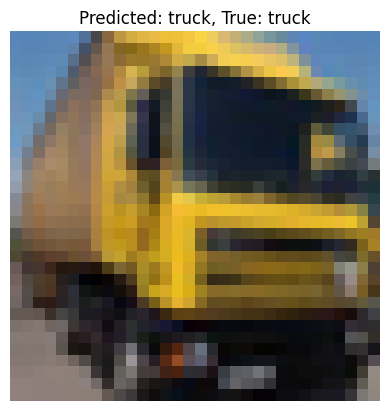

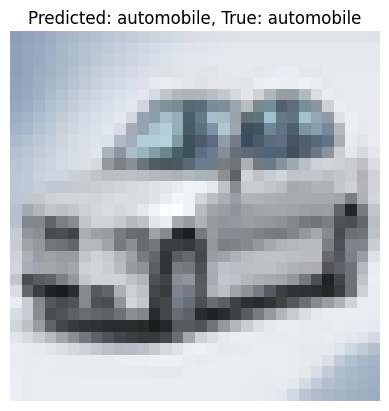

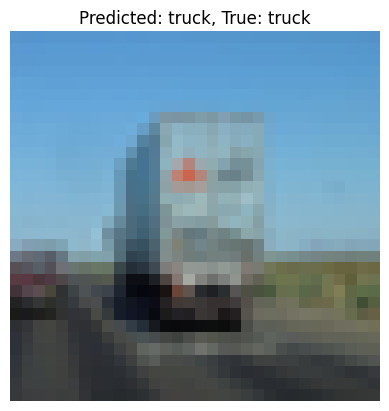

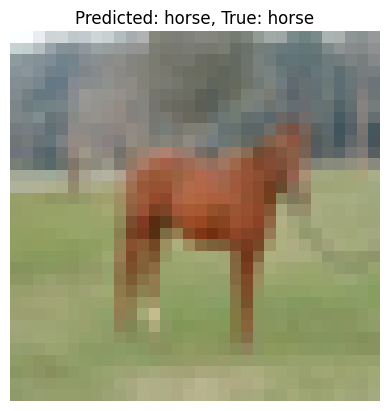

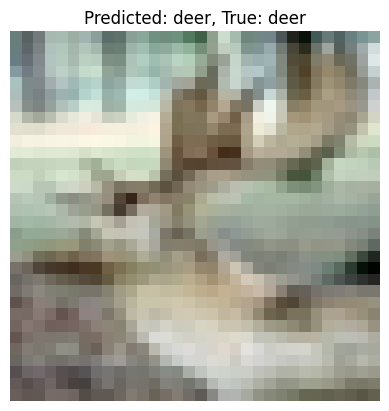

In [ ]:
# Choose random test images for visualization
num_samples = 5
random_indices = np.random.randint(0, len(X_test), num_samples)
random_images = X_test[random_indices]

# Make predictions
predictions = model.predict(random_images)

# Plot the random test images along with their predicted classes
for i in range(num_samples):
    plt.imshow(random_images[i])
    plt.title(f"Predicted: {class_names[np.argmax(predictions[i])]}, True: {class_names[np.argmax(y_test[random_indices[i]])]}")
    plt.axis('off')
    plt.show()


Saving Model

In [ ]:
import pickle

# save the image classification model as a pickle file
model_pkl_file = "image_classification_model.pkl"

with open(model_pkl_file, 'wb') as file:
    pickle.dump(model, file)

In [ ]:
# load model from pickle file
with open(model_pkl_file, 'rb') as file:
    model = pickle.load(file)